<h1>Project: Association Rule</h1>
<h2>Utilizing Association Rule to determine the relationship between book (Genre and setting (Location utilized in the story)) and rating provided by users</h2>

<h5><div><b>Abstract</b></div>
<div>This project applies association‑rule analysis to the Goodreads Best Books Ever dataset (captured from https://www.goodreads.com/) to explore how book genre and story setting locations correlate with user‑assigned ratings. By utilizing available data for each book, Apriori algorithm is applied on top of the same to identify frequent genres and extract rules that reveal meaningful relationships between it and ratings provided by readers. The resulting rules highlight which combinations of genres or location settings are most strongly associated with higher ratings, offering insights that can support personalized recommendation systems and guide both readers and publishers toward preference‑aligned selections.</div></h5>

<h5>Installing Necessary libraries for performing required Association Rule analysis</h5>

In [475]:
!pip install numpy
!pip install pandas

In [476]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

<h4>Data Set utilized for the same: <b>Goodreads' Best Books Ever</b></h4>
<h4>Link to Data Set : https://www.kaggle.com/datasets/arnabchaki/goodreads-best-books-ever</h4>

The data set contains 52478 rows each representing a book and 23 features representing title, author, genre, awards won by the book, rating etc.

Out of the 23 features we plan to utilize only title, rating, genre and setting for the purpose of analysis.

Also the number of unique genres and settings calculated at a later step is too large thus, we plan to select a smaller sample of 120 rows from the data set for analysis.

<h5>Proceeding for Data Set import</h5>

In [477]:
# Reading the csv data set
data = pd.read_csv('books_1.Best_Books_Ever.csv')
data.head()

,title,series,author,rating,description,language,isbn,genres,characters,bookFormat,...,publishDate,firstPublishDate,awards,numRatings,ratingsByStars,likedPercent,setting,bbeScore,bbeVotes,price
0,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,9.78044E+12,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...",Hardcover,...,09/14/08,NaN,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,"['District 12, Panem', 'Capitol, Panem', 'Pane...",2993816,30516,5.09
1,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9.78044E+12,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",Paperback,...,09/28/04,06/21/03,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,2632233,26923,7.38
2,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,1E+13,"['Classics', 'Fiction', 'Historical Fiction', ...","['Scout Finch', 'Atticus Finch', 'Jem Finch', ...",Paperback,...,05/23/06,07-11-1960,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,"['Maycomb, Alabama (United States)']",2269402,23328,NaN
3,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,1E+13,"['Classics', 'Fiction', 'Romance', 'Historical...","['Mr. Bennet', 'Mrs. Bennet', 'Jane Bennet', '...",Paperback,...,10-10-2000,01/28/13,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,"['United Kingdom', 'Derbyshire, England (Unite...",1983116,20452,NaN
4,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,9.78032E+12,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Edward Cullen', 'Jacob Black', 'Laurent', 'R...",Paperback,...,09-06-2006,10-05-2005,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,"['Forks, Washington (United States)', 'Phoenix...",1459448,14874,2.1


<h5>Analyzing the data set and relationship between different features. Can rating column be generated from mean of ratingsByStar column and numRatings data can be generated as a sum of ratingsByStar array aggregate sum.</h5>

In [478]:
data['ratingsByStars'] = data['ratingsByStars'].astype(str)

# Function to convert ratingsByStars string to list of integers
def parse_star_list(x):
    x = x.strip()
    x = x.strip('[]')
    parts = x.replace("'", "").split(',')
    return [int(p.strip()) for p in parts if p.strip().isdigit()]

data['ratingsByStarsParsed'] = data['ratingsByStars'].apply(parse_star_list)

# Sum the values
data['sumRatingsByStars'] = data['ratingsByStarsParsed'].apply(sum)

# Compare with numRatings
data['isSumCorrect'] = data['numRatings'] == data['sumRatingsByStars']

# Inspect
data[['ratingsByStarsParsed', 'sumRatingsByStars', 'numRatings', 'isSumCorrect']].head()

# Number of rows with isSumCorrect as False
removed_rows = data[~data['isSumCorrect']]
removed_rows.shape
removed_rows[['numRatings', 'sumRatingsByStars', 'ratingsByStarsParsed']].describe(include='all')

,numRatings,sumRatingsByStars,ratingsByStarsParsed
count,1352.000000,1352.0,1352
unique,NaN,NaN,1
top,NaN,NaN,[]
freq,NaN,NaN,1352
mean,10.054734,0.0,NaN
std,279.378418,0.0,NaN
min,1.000000,0.0,NaN
25%,2.000000,0.0,NaN
50%,2.000000,0.0,NaN
75%,3.000000,0.0,NaN


<h5>The same indicates that numRatings column contains redundant data and can be dropped</h5>

In [479]:
# Dropping numRatings, sumRatingsByStars, ratingsByStars as they are no longer needed
data = data.drop(columns=['numRatings', 'sumRatingsByStars', 'ratingsByStars'])

# Cross checking if ratingsByStarsParsed always has length 5
data['ratingsByStarsLength'] = data['ratingsByStarsParsed'].apply(len)
print(data['ratingsByStarsLength'].value_counts())


ratingsByStarsLength
5    51055
0     1423
Name: count, dtype: int64


<h5>Crosschecking the Rating Column value in case of zero length of ratingsByStars array</h5>

In [480]:

# select rows where sumRatingsByStars is not equal to numRatings
invalid_rows = data[~data['isSumCorrect']]
# Summarizing these rows
invalid_rows[['rating', 'ratingsByStarsParsed']].describe(include='all')

,rating,ratingsByStarsParsed
count,1352.000000,1352
unique,NaN,1
top,NaN,[]
freq,NaN,1352
mean,4.537722,NaN
std,0.633256,NaN
min,1.000000,NaN
25%,4.000000,NaN
50%,5.000000,NaN
75%,5.000000,NaN


<h5>The columns with blank ratingsByStarsParsed array cause inconsistency and thus, should be removed</h5>

In [481]:
# removing rows with inconsistency in sum of ratingsByStars and numRatings
data = data[data['isSumCorrect']]

# removing isSumCorrect column since its no longer needed
data = data.drop(columns=['isSumCorrect'])

<h5>Calculating relation between ratingsByStarsParsed and rating features from the data set.</h5>

In [482]:
# looping over ratingsByStarsParsed and multiplying each element by its star value (5 to 1)
def compute_weighted_rating(ratings_list):
    weighted_sum = sum((5-i) * ratings_list[i] for i in range(len(ratings_list)))
    total_ratings = sum(ratings_list)
    if total_ratings == 0:
        return 0
    return weighted_sum / total_ratings

data['computed_rating'] = data['ratingsByStarsParsed'].apply(compute_weighted_rating)

# Diving computed_rating by sum of ratingsByStarsParsed to get average rating and see if it matches with rating column
data['computed_average_rating'] = data['computed_rating']
data[['rating', 'computed_average_rating']].head()

,rating,computed_average_rating
0,4.33,4.325370
1,4.50,4.497903
2,4.28,4.277340
3,4.26,4.262180
4,3.60,3.599703


<h5>The same clears our interpretation and thus, ratingsByStarsParsed column can be dropped and only Ratings column can be considered for an aggregate rating</h5>

In [483]:
# dropping ratingsByStarsLength and computed_rating as they are no longer needed
data = data.drop(columns=['ratingsByStarsLength', 'computed_rating'])

# keeping the needed columns like title, rating, genres, settings for association rule implementation
data = data[['title', 'rating', 'genres', 'setting']]
data.head()

,title,rating,genres,setting
0,The Hunger Games,4.33,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['District 12, Panem', 'Capitol, Panem', 'Pane..."
1,Harry Potter and the Order of the Phoenix,4.50,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...",['Hogwarts School of Witchcraft and Wizardry (...
2,To Kill a Mockingbird,4.28,"['Classics', 'Fiction', 'Historical Fiction', ...","['Maycomb, Alabama (United States)']"
3,Pride and Prejudice,4.26,"['Classics', 'Fiction', 'Romance', 'Historical...","['United Kingdom', 'Derbyshire, England (Unite..."
4,Twilight,3.60,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Forks, Washington (United States)', 'Phoenix..."


<h5>Analyzing genres and settings array to notice the number of distinct values</h5>

In [484]:
# Number of unique genres from each array in genres column
unique_genres = set()
for genre_list in data['genres']:
    genres_string = genre_list.strip().strip('[]').replace("'", "")
    for genre in genres_string.split(','):
        unique_genres.add(genre.strip())
print(f"Number of unique genres: {len(unique_genres)}")
# print(unique_genres)

# Number of unique settings from each array in setting column
unique_settings = set()
for setting_list in data['setting']:
    settings_string = setting_list.strip().strip('[]').replace("'", "")
    for setting in settings_string.split(','):
        unique_settings.add(setting.strip())
print(f"Number of unique settings: {len(unique_settings)}")
# print(unique_settings)

Number of unique genres: 983
Number of unique settings: 4181


<h5>Owing to the large number of genres and settings, we are sampling a small portion of the data set</h5>

In [485]:
# sampling 120 rows for faster processing and computation
data = data.sample(n=120, random_state=17).reset_index(drop=True)
data.head()

,title,rating,genres,setting
0,Witchling,3.65,"['Urban Fantasy', 'Paranormal', 'Fantasy', 'Pa...","['Seattle, Washington (United States)']"
1,"Delirium Stories: Hana, Annabel, and Raven",3.92,"['Young Adult', 'Dystopia', 'Short Stories', '...",[]
2,Over the Edge of the World: Magellan's Terrify...,4.12,"['History', 'Nonfiction', 'Biography', 'Advent...",[]
3,Firespell and Hexbound,4.07,"['Young Adult', 'Paranormal', 'Vampires', 'Fan...",[]
4,Beyond Every Mirror,3.77,"['Fantasy', 'Fiction']",[]


<h5>Analyzing genres and settings array to notice the number of distinct values</h5>

In [486]:
# Number of unique genres from each array in genres column
unique_genres = set()
for genre_list in data['genres']:
    genres_string = genre_list.strip().strip('[]').replace("'", "")
    for genre in genres_string.split(','):
        unique_genres.add(genre.strip())
print(f"Number of unique genres: {len(unique_genres)}")
# print(unique_genres)

# Number of unique settings from each array in setting column
def parse_list(s):
    s = s.strip()[1:-1]
    parts = [p.strip().strip("'").strip('"') for p in s.split(',')]
    return parts

data['setting'] = data['setting'].apply(parse_list)

def clean_settings(lst):
    cleaned = []
    for item in lst:
        match = re.search(r'\((.*?)\)', item)
        cleaned_item = match.group(1) if match else item
        if cleaned_item.strip() != "":
            cleaned.append(cleaned_item)
    return cleaned

data['setting'] = data['setting'].apply(clean_settings)

unique_settings = {s for lst in data['setting'] for s in lst if s.strip() != ""}
print(f"Number of unique settings: {len(unique_settings)}")
print(unique_settings)

Number of unique genres: 227
Number of unique settings: 32
{'Bahamas', 'Seattle', 'Washington', 'Pacific Ocean', 'Moon', 'Brobdingnag', 'Boston', 'Turkey', 'Mediterranean Sea', 'Russian Federation', 'Asteroid Belt', 'Antarctica', 'France', 'North London', 'Mars', 'Charlottesville', 'Italy', 'Atlantis', 'Lakeview', 'Papua New Guinea', 'Red Sea', 'United Kingdom', 'West Africa', 'New York City', 'United States of America', 'Lilliput', 'Palmetto', 'Undisclosed', 'Las Vegas', 'Indian Ocean', 'Cincinnati', 'United States'}


<h5>Observing top 20 most frequently occuring genres and setting values</h5>

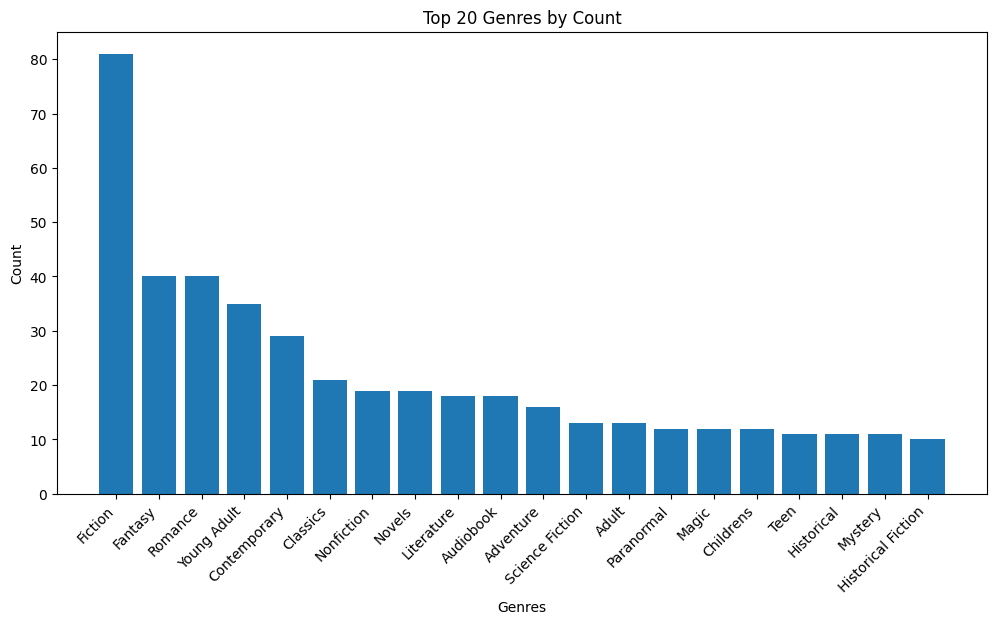

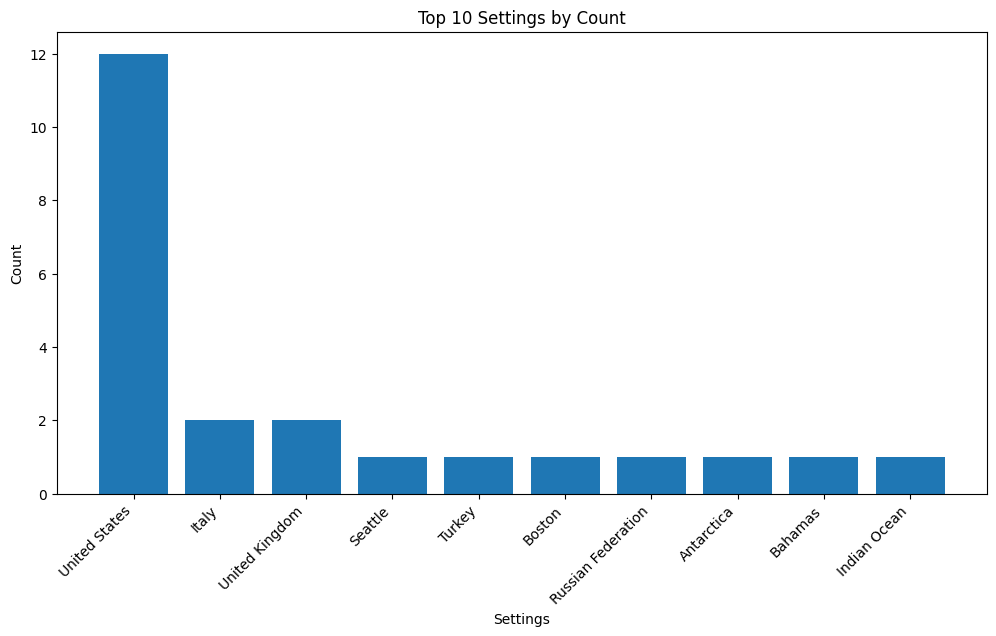

In [487]:
# bar chart for top 20 genres and their counts
genre_counts = Counter()
for genre_list in data['genres']:
    genres_string = genre_list.strip().strip('[]').replace("'", "")
    for genre in genres_string.split(','):
        genre_counts[genre.strip()] += 1
top_genres = genre_counts.most_common(20)
genres, counts = zip(*top_genres)
plt.figure(figsize=(12, 6))
plt.bar(genres, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Genres by Count')
plt.xlabel('Genres')
plt.ylabel('Count')
plt.show()

# bar chart for top 10 settings and their counts
setting_counts = Counter()
for setting_list in data['setting']:
    for setting in setting_list:
        setting_counts[setting.strip()] += 1
top_settings = setting_counts.most_common(10)
settings, counts = zip(*top_settings)
plt.figure(figsize=(12, 6))
plt.bar(settings, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Settings by Count')
plt.xlabel('Settings')
plt.ylabel('Count')
plt.show()